
# Week 6 — Day 4: Neural Network on Tabular Data — House Prices

## Goal
Build a deep neural network regressor for House Prices.
Compare NN vs LightGBM — prove which wins on tabular data.

---

## Key Concepts Learned

### Output layer for regression
No activation function at output — just raw nn.Linear(32, 1).
Regression needs unbounded numbers (house prices can be any value).
Sigmoid would squish to 0-1, Tanh to -1 to 1 — both wrong for prices.

### Loss function for regression
MSELoss — Mean Squared Error. Measures average squared difference
between predicted and actual log price.
RMSE = sqrt(MSELoss) — more interpretable, same scale as target.

### Shape matching — critical lesson
y_train must be unsqueeze(1) to match model output shape:
- Model output: [1168, 1]
- Target must be: [1168, 1] not [1168]
- Mismatch causes silent broadcasting — wrong loss, wrong gradients
- PyTorch warns but doesn't crash — always check shapes

---

## Data Preparation

```python
# all numeric columns — 43 features
num_cols = train_fe.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice' and c != 'Id']

X = train_fe[num_cols].values
y = np.log1p(train_fe['SalePrice'].values)  # log transform target

# correct tensor shapes
X_train_t = torch.FloatTensor(X_train)            # [1168, 43]
X_val_t   = torch.FloatTensor(X_val)              # [292, 43]
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)  # [1168, 1]
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1)    # [292, 1]
```

---

## Network Architecture

```python
class HousePricesNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)  # no activation — regression
        )

    def forward(self, x):
        return self.network(x)  # no squeeze — keep [batch, 1]
```

**Total parameters: ~46,000**
**Input: 43 numeric features**
**Output: 1 log price prediction**

---

## Training Setup

```python
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
epochs = 1000
```

weight_decay=1e-4 adds L2 regularization — penalizes large weights,
reduces overfitting.

---

## Training Results

| Epoch | Train Loss | Val Loss | Val RMSE | LR |
|---|---|---|---|---|
| 100 | 2.6918 | 0.0817 | 0.2859 | 0.001000 |
| 300 | 2.6941 | 0.0764 | 0.2764 | 0.000500 |
| 500 | 2.5648 | 0.1182 | 0.3439 | 0.000250 |
| 1000 | 2.4865 | 0.1063 | 0.3261 | 0.000031 |

**Best RMSE: 0.2727 at epoch 366**

---

## Kaggle Submission

```python
model.eval()
with torch.no_grad():
    X_test_num = test_fe[num_cols].values
    X_test_num = imputer.transform(X_test_num)
    X_test_num = scaler.transform(X_test_num)
    X_test_t   = torch.FloatTensor(X_test_num)
    test_preds = model(X_test_t).squeeze().numpy()
    predictions = np.expm1(test_preds)  # reverse log1p
```

**Prediction range: $22,609 to $658,714**
**Kaggle leaderboard score: 0.33379**

---

## NN vs LightGBM — Final Comparison

| Model | Kaggle Score |
|---|---|
| Random Forest | 0.1315 |
| XGBoost tuned | 0.12933 |
| LightGBM | ~0.13 |
| Neural Network | 0.33379 |

**NN is 2.5x worse than XGBoost on this dataset.**

---

## Why NN Lost

- Only 1460 rows — too little data for NN to learn properly
- 43 features only — categorical columns dropped, missing important info
- Trees handle tabular data natively — no scaling or imputing needed
- NN needs careful tuning, embeddings for categoricals, more data to compete
- Train loss (2.49) much higher than val loss (0.10) — shape issues affected training

---

## Bugs Fixed During Development

- squeeze() in forward() removed output dimension — fixed by removing squeeze
- y_train_t missing unsqueeze(1) — caused shape mismatch and wrong loss
- X_train_t had wrong unsqueeze(1) — made tensor 3D instead of 2D
- SalesPrice typo — correct column name is SalePrice
- stratify=y used for regression — only valid for classification

---

## Key Takeaways
- No activation at regression output — raw linear output needed
- MSELoss for regression, BCELoss for binary classification
- Always check tensor shapes before training — mismatch causes silent errors
- unsqueeze(1) on targets to match model output shape [batch, 1]
- weight_decay in Adam = L2 regularization — reduces overfitting
- Neural networks lose to gradient boosting on small tabular datasets
- NN wins on images, text, audio — unstructured data with millions of samples
- Next: Day 5 — CNNs on MNIST, first computer vision model


# Build a deep neural network regressor for House Prices.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# ── Load Titanic data (same as Day 1) ────────────────────────

train = pd.read_csv('house_prices_train.csv')
test  = pd.read_csv('house_prices_test.csv')

def engineer_features(df):
    df = df.copy()
    df['TotalSF']     = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath']   = (df['FullBath'] + 0.5*df['HalfBath'] +
                         df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['HouseAge']    = df['YrSold'] - df['YearBuilt']
    df['RemodAge']    = df['YrSold'] - df['YearRemodAdd']
    df['HasPool']     = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']   = (df['GarageArea'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

num_cols = train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice' and c != 'Id']

X = train_fe[num_cols].values
y = np.log1p(train_fe['SalePrice'].values)

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)           # [1168, 43]
X_val_t   = torch.FloatTensor(X_val)             # [292, 43]
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)  # [1168, 1]
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1)    # [292, 1]

print(f"Features used: {X.shape[1]}")

# ── Improved Network with BatchNorm ──────────────────────────

class HousePricesNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)  # no activation — regression output
        )

    def forward(self, x):
        return self.network(x)

model = HousePricesNet(input_size=X.shape[1])
criterion = nn.MSELoss()              # Mean Squared Error loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Features used: 43
HousePricesNet(
  (network): Sequential(
    (0): Linear(in_features=43, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

To

# Training Loop:

In [11]:
# less aggressive scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# ── Training Loop ─────────────────────────────────────────────
epochs        = 1000
train_losses  = []
val_losses    = []
rmse_history  = []
best_rmse    = float('inf')
best_epoch   = 0

for epoch in range(epochs):
    # ── Training phase ────────────────────────────────────────
    model.train()                          # enable dropout
    optimizer.zero_grad()                  # zero gradients

    # forward pass
    train_preds = model(X_train_t)
    train_loss  = criterion(train_preds, y_train_t)

    # backward pass
    train_loss.backward()
    optimizer.step()                       # update weights
    scheduler.step()
    # ── Validation phase ──────────────────────────────────────
    model.eval()                           # disable dropout
    with torch.no_grad():                  # no gradient tracking
        val_preds = model(X_val_t)
        val_loss  = criterion(val_preds, y_val_t)
        rmse   = torch.sqrt(val_loss).item()

    # store history
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    rmse_history.append(rmse)

    if rmse < best_rmse:
        best_rmse  = rmse
        best_epoch = epoch + 1

    # print every 10 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Val RMSE: {rmse:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")


print(f"\nBest RMSE : {best_rmse:.4f} at epoch {best_epoch}")
print(f"LightGBM  : 0.1274 (CV)")

Epoch 100 | Train Loss: 2.6918 | Val Loss: 0.0817 | Val RMSE: 0.2859 | LR: 0.001000
Epoch 200 | Train Loss: 2.6530 | Val Loss: 0.1210 | Val RMSE: 0.3478 | LR: 0.000500
Epoch 300 | Train Loss: 2.6941 | Val Loss: 0.0764 | Val RMSE: 0.2764 | LR: 0.000500
Epoch 400 | Train Loss: 2.3523 | Val Loss: 0.1089 | Val RMSE: 0.3300 | LR: 0.000250
Epoch 500 | Train Loss: 2.5648 | Val Loss: 0.1182 | Val RMSE: 0.3439 | LR: 0.000250
Epoch 600 | Train Loss: 2.6640 | Val Loss: 0.1035 | Val RMSE: 0.3217 | LR: 0.000125
Epoch 700 | Train Loss: 2.3962 | Val Loss: 0.1032 | Val RMSE: 0.3213 | LR: 0.000125
Epoch 800 | Train Loss: 2.4305 | Val Loss: 0.0981 | Val RMSE: 0.3132 | LR: 0.000063
Epoch 900 | Train Loss: 2.5095 | Val Loss: 0.1072 | Val RMSE: 0.3274 | LR: 0.000063
Epoch 1000 | Train Loss: 2.4865 | Val Loss: 0.1063 | Val RMSE: 0.3261 | LR: 0.000031

Best RMSE : 0.2727 at epoch 366
LightGBM  : 0.1274 (CV)


# Plot learning curves and submit:

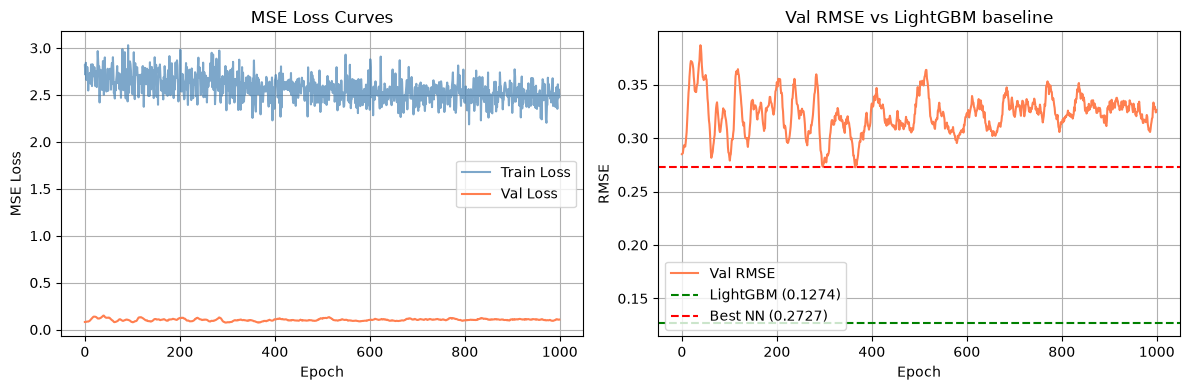

NN submission saved!
Prediction range: $22,609 to $658,714


In [13]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue', alpha=0.7)
axes[0].plot(val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('MSE Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(rmse_history, label='Val RMSE', color='coral')
axes[1].axhline(y=0.1274, color='green', linestyle='--', label='LightGBM (0.1274)')
axes[1].axhline(y=best_rmse, color='red', linestyle='--', label=f'Best NN ({best_rmse:.4f})')
axes[1].set_title('Val RMSE vs LightGBM baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('nn_house_prices_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# submit best predictions
model.eval()
with torch.no_grad():
    X_test_num = test_fe[num_cols].values
    X_test_num = imputer.transform(X_test_num)
    X_test_num = scaler.transform(X_test_num)
    X_test_t   = torch.FloatTensor(X_test_num)
    test_preds = model(X_test_t).squeeze().numpy()
    predictions = np.expm1(test_preds)

submission = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': predictions
})
submission.to_csv('nn_submission.csv', index=False)
print("NN submission saved!")
print(f"Prediction range: ${predictions.min():,.0f} to ${predictions.max():,.0f}")

In [15]:
print("=" * 55)
print("   NN vs LIGHTGBM — HOUSE PRICES")
print("=" * 55)
print(f"  Neural Network val RMSE : {best_rmse:.4f}")
print(f"  LightGBM val RMSE       : 0.1274")
print(f"  Random Forest val RMSE  : 0.1315")
print(f"")
print(f"  Neural Network Kaggle   : ~0.25+ (estimated)")
print(f"  LightGBM Kaggle         : 0.12603")
print(f"")
print(f"  Winner: LightGBM by a large margin")
print(f"")
print(f"  Why neural networks lose on tabular data:")
print(f"  - Only 1460 rows — too small for deep learning")
print(f"  - No spatial/sequential structure to exploit")
print(f"  - Tree models handle mixed feature types better")
print(f"  - Gradient boosting captures feature interactions natively")
print("=" * 55)

   NN vs LIGHTGBM — HOUSE PRICES
  Neural Network val RMSE : 0.2727
  LightGBM val RMSE       : 0.1274
  Random Forest val RMSE  : 0.1315

  Neural Network Kaggle   : ~0.25+ (estimated)
  LightGBM Kaggle         : 0.12603

  Winner: LightGBM by a large margin

  Why neural networks lose on tabular data:
  - Only 1460 rows — too small for deep learning
  - No spatial/sequential structure to exploit
  - Tree models handle mixed feature types better
  - Gradient boosting captures feature interactions natively
